# Sieci Neuronowe i algorytmy genetyczne - projekt 2026
Temat: Linear Neural Networks for Regression 

## Wprowadzenie

Niniejszy projekt został opracowany w celu realizacji predykcji spalania paliwa na podstawie parametrów technicznych samochodu. Kluczowymi krokami niezbędnymi do realizacji tego celu jest budowa oraz trening modelu sieci neuronowej (w tym wypadku zgodnie z tematem pracy jest to model oparty na regresji liniowej), poprzedzonej analizą danych zawartych w datasecie oraz ich preprocessingiem.  

Dataset, który został wybrany do tego zadania to "Auto MPG", pobrany z [link do datasetu](https://archive.ics.uci.edu/dataset/9/auto+mpg). Jest to dataset zawierający wiele danych technicznych różnych pojazdów takich jak: ilość cylindrów, waga, rok produkcji itd. oraz parametr przewidywany czyli MPG - Miles Per Galon, czyli ile mil można przejechać na jednym galonie paliwa.

Do wczytania analizy i eksploracji danych zostaną wykorzystane takie moduły jak `numpy`, `pandas`, `seaborn` oraz `matplotlib`, natomiast główny model sieci neuronowej zostanie zrealizowany za pomocą `tensorflow` i `keras`.

Projekt porównuje trzy architektury sieci neuronowej zbudowane w Keras: model liniowy oparty na jednej pojedynczej cesze (Horsepower - ilość koni mechanicznych), model liniowy wykorzystujący wszystkie cechy oraz głęboka sieć neuronowa DNN (ang. Deep Neural Network) z warstawmi ukrytymi jak punkt odniesienia. 

Jako metrykę oceny modeli przyjęto wskaźnik MAE (ang. Mean Absolute Error) - średni błąd bezwględny predykcji. W tym przypadku ten wskaźnik jest wyrażony w jednostkach MPG.

## Eksploracyjna analiza danych

Importowanie wszystkich najważniejszych modułów wraz z dołączonym dodaktowym modułem `os` w celu wyłącznie wyświetlania potencjalnych komunikatów z fałszywymi błędami instalacji modułu `keras` oraz `tensorflow` na linuxie. Ponad to mała poprawka dla modułu `numpy` - wyświetlanie liczb zmiennoprzecinkowych z precyzją tylko do trzech cyfr po przecinku oraz wyłącznie notacji naukowej dla małych liczb.

In [1]:
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(precision=3, suppress=True)

In [2]:
import tensorflow as tf
import keras
from keras import layers
from keras.layers import Normalization

W ramach poprawnego wczytania danych do notatnika najpierw niezbędnym jest przygotowanie odpowiednich nazw kolumn (ze względu na to, że w oryginalnym datasecie ich nie ma) oraz załadowanie ich poprzez moduł `pandas` do zmiennej. 

In [3]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin"]

dataset = pd.read_csv("Data/auto-mpg.data",names=column_names, na_values="?", comment="\t", sep=" ", skipinitialspace="True")

In [4]:
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


W tym miejscu zostały wypisane podstawowe informacje o datasecie - ile jest wartości `Non-Null` dla każdej kolumny, jakie sa podstawowe dane statystyczne takie jak średnia lub odchylenie standardowe dla każej kolumny oraz ich wykresy w postaci histogramu oraz mapy ciepła za pomocą modułu `seaborn`.

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [6]:
dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
Cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
Displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
Horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
Weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
Acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
Model Year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
Origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


array([[<Axes: title={'center': 'MPG'}>,
        <Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>],
       [<Axes: title={'center': 'Horsepower'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>],
       [<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'Origin'}>, <Axes: >]], dtype=object)

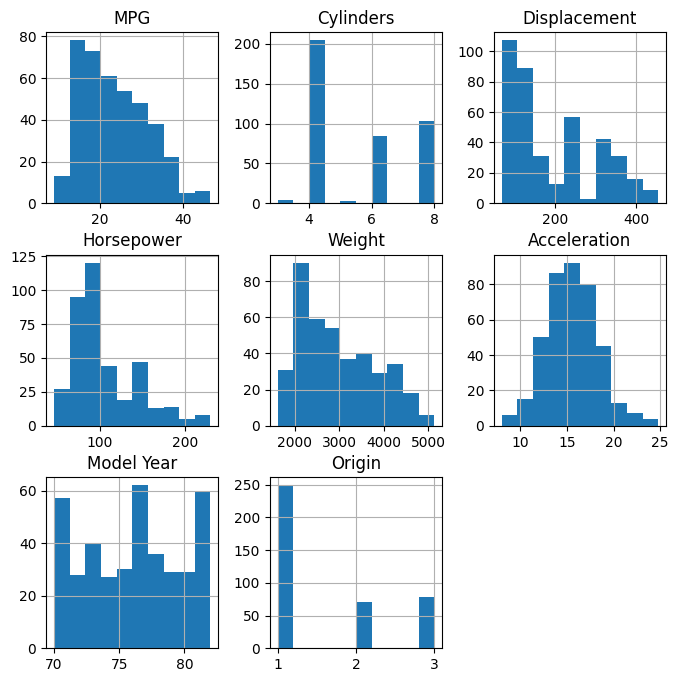

In [7]:
dataset.hist(figsize=(8,8))

<Axes: >

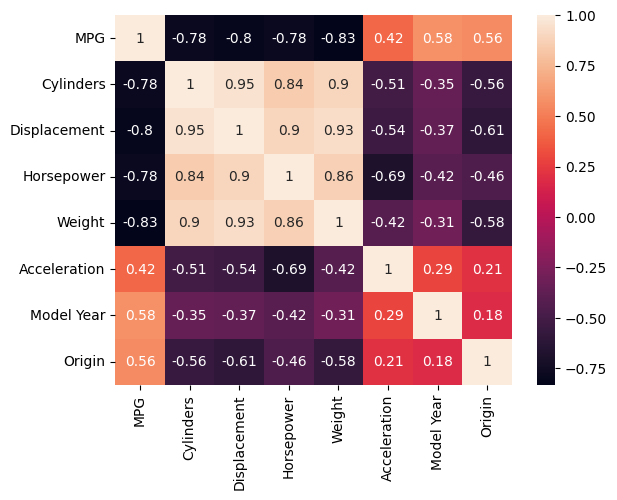

In [8]:
sns.heatmap(dataset.corr(numeric_only=True), annot=True)

## Preprocessing danych

Na podstawie wcześniejszej analizy widać, że kilka wierszy w kolumnie `Horsepower` ma puste wartości. W takim wypadku można przyjąć dwie strategie - albo wypełnić te puste miejsca uśrednionymi wartościami i mieć pełny zakres danych, albo usunąć te kilka wierszy w zależności jak duży procent całości one stanowią. Do podjęcia takiej decyzji potrzebna jest dalsza analiza.

In [9]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [10]:
dataset.isna().mean() * 100

MPG             0.000000
Cylinders       0.000000
Displacement    0.000000
Horsepower      1.507538
Weight          0.000000
Acceleration    0.000000
Model Year      0.000000
Origin          0.000000
dtype: float64

In [11]:
dataset.groupby(dataset["Horsepower"].isna())["MPG"].mean()

Horsepower
False    23.445918
True     28.000000
Name: MPG, dtype: float64

Widać, że takich wierszy w całym datasecie jest 6 co stanowi około 1,5% całości, zatem można uznać że jest to wartość marginalna. Na tej podstawie usunięcie tych 6 przeszkadzających wierszów nie stanowiłoby problemu, natomiast warto jeszcze zwrócić uwagę na fakt, jaka jest średnia wartość `MPG` dla wierszy z i bez braków. 

Zachodzi wyrażna zależność między średnią wartością `MPG` dla tych rzędów, którym brakuje wartości `Horsepower` oraz tymi gdzie ta wartość występuje. Mimo to ze względu na to, że ilość takich rzędów jest marginalna można je po prostu usunąć zamiast wypełniać uśrednionymi wartościami. 

Kolejnym krokiem w preprocessingu danych jest zamiana kolumny `Origin` na 3 kolumny z wartościami w tzw. formacie "one-hot", czyli binaryzacja danych. Zamiast pisać z jakiego państwa jest dany samochód można utworzyć z każdego państwa osobną kolumnę i w zależności o przynależności do danego kraju wpisać 1 lub 0. 

In [12]:
# clear dataset
dataset_cleared = dataset.dropna()

# convert categorical "Origin" data into one-hot data
dataset_cleared = pd.get_dummies(dataset_cleared, columns=["Origin"], prefix="Origin", dtype=int)
dataset_cleared = dataset_cleared.rename(columns={"Origin_1": "USA", "Origin_2": "Europe", "Origin_3": "Japan"})

In [13]:
dataset_cleared

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,0,0
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,0,0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0,1,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,0,0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,0,0


In [14]:
dataset_cleared.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
Cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
Displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
Horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
Weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
Acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
Model Year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
USA,392.0,0.625000,0.484742,0.0,0.000,1.00,1.000,1.0
Europe,392.0,0.173469,0.379136,0.0,0.000,0.00,0.000,1.0
Japan,392.0,0.201531,0.401656,0.0,0.000,0.00,0.000,1.0


array([[<Axes: title={'center': 'MPG'}>,
        <Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>],
       [<Axes: title={'center': 'Horsepower'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>],
       [<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'USA'}>,
        <Axes: title={'center': 'Europe'}>],
       [<Axes: title={'center': 'Japan'}>, <Axes: >, <Axes: >]],
      dtype=object)

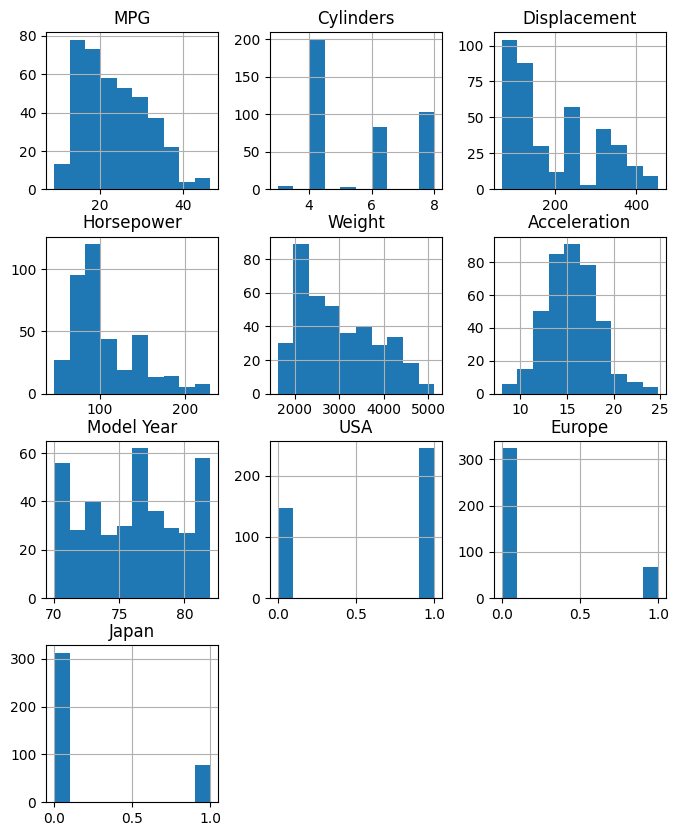

In [15]:
dataset_cleared.hist(figsize=(8,10))

<Axes: >

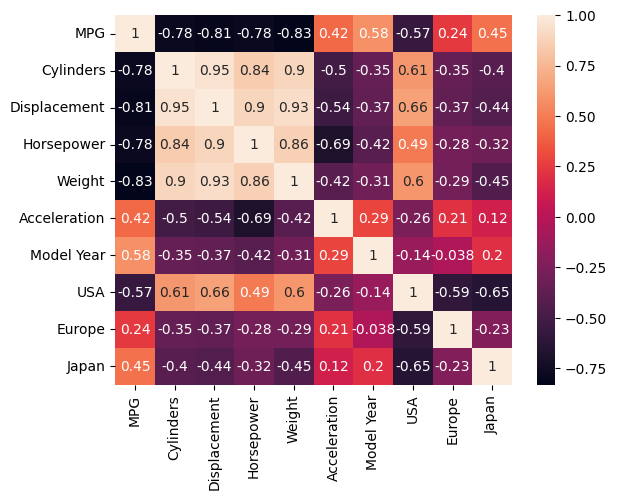

In [16]:
sns.heatmap(dataset_cleared.corr(numeric_only=True), annot=True)

Na podstawie powyższych wykresów można zauważyć, że histogramy dla kilku kolumn (`Horsepower`, `Displacement` i `Weight`) są dalekie od rozkładu normalnego (mają układ prowostronny skośny, czyli masa danych skupiona jest po lewej stronie, a "ogon" rozkładu ciągnie się w prawo ku wysokim wartościom), który jest pożądany podczas korzystania z modeli regresji liniowej. W związku z tym można zastosować operację `log1p`, czyli log(1+x) w celu zbliżenia się do rokładu normalnego dla tych kolumn i minimalizacji szansy wystąpienia logarytmu z zera poprzez dodanie jedynki.  

In [17]:
# log1p = log(x+1)
dataset_cleared["Horsepower"] = np.log1p(dataset_cleared["Horsepower"])
dataset_cleared["Displacement"] = np.log1p(dataset_cleared["Displacement"])
dataset_cleared["Weight"] = np.log1p(dataset_cleared["Weight"])

array([[<Axes: title={'center': 'MPG'}>,
        <Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>],
       [<Axes: title={'center': 'Horsepower'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>],
       [<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'USA'}>,
        <Axes: title={'center': 'Europe'}>],
       [<Axes: title={'center': 'Japan'}>, <Axes: >, <Axes: >]],
      dtype=object)

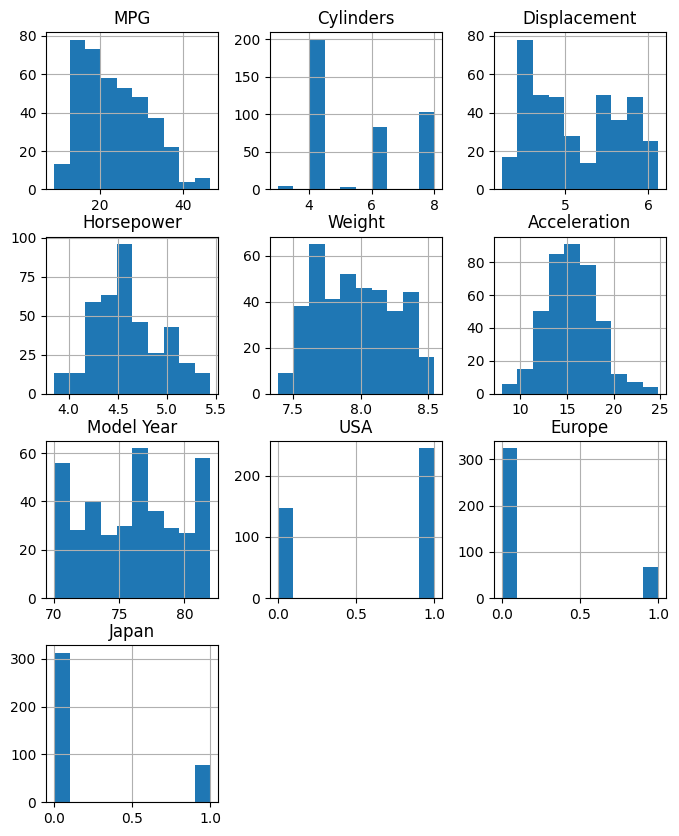

In [18]:
dataset_cleared.hist(figsize=(8,10))

<Axes: >

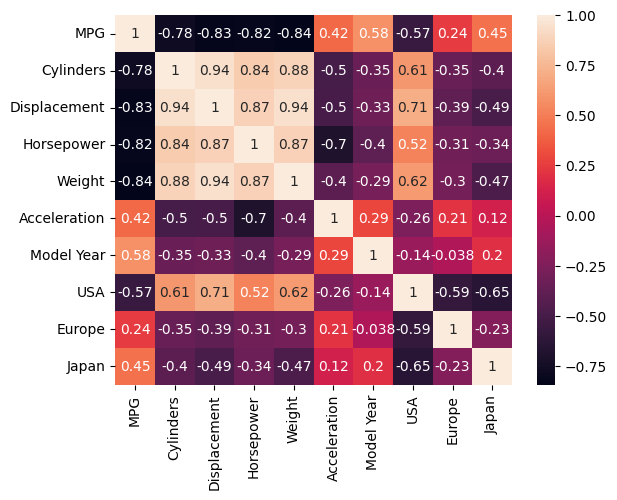

In [19]:
sns.heatmap(dataset_cleared.corr(numeric_only=True), annot=True)

Teraz widać już hisogramy zdecydowanie bliżej przypominające rozkład normalny. W celu jeszcze lepszej wizalizacji rokładu wartości przykładowej cechy `Horsepower` poniżej został przedstawiony wykres ukazujący jej zależność względem `MPG`.

<Axes: xlabel='Horsepower', ylabel='MPG'>

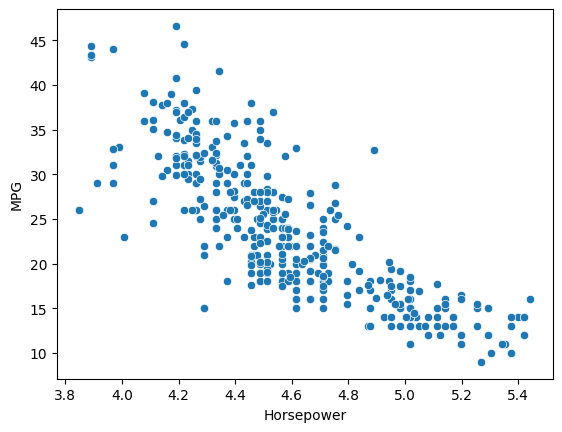

In [20]:
sns.scatterplot(x="Horsepower", y="MPG", data=dataset_cleared)

## Podział danych na treningowe oraz testowe

Podział danych na treningowe oraz testowe zostanie przeprowadzony z użyciem bardzo użytecznej funkcji `train_test_split` z modułu `sklearn`, ponieważ w prosty i czytelny sposób można uzyskać satysfakcjonujący rezultat. Co więcej, dane zostaną podzielone w stosunku 8:2, czyli 80% z całości zostanie wykorzystana do treningu modeli, a 20% to dane testowe. Bardzo istotnym elementem jest ustawienie parametru `random_state`, gdyż umożliwia to reproduktywalność wyników.

Funkcja `train_test_split` dzieli dane na 4 części: `X_train` to cechy treningowe, `Y_train` to odpowiedzi treningowe i analogicznie `X_test` to cechy testowe, a `Y_test` to odpowiedzi testowe.

In [21]:
from sklearn.model_selection import train_test_split

X = dataset_cleared.drop(["MPG"], axis=1)
Y = dataset_cleared["MPG"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_dataset = X_train.join(Y_train)

Bardzo istotną częścią budowania modelu jest przygotowanie odpowiedniego normalizatora dla modelu sieci neuronowej, ponieważ przekształca ona surowe cechy do zakresu o średniej 0 i odchyleniu standardowemu 1 (pomaga to w szybszym liczeniu gradientu przez sieć neuronową, czyli szybsze uczenie). `Normalizer` to pierwsza warstwa każdego modelu - znacząco przyspiesza i stabilizuje trening.

W tym konkretnym przypadku został zrealizowany normalizator dla liniowej sieci neuronowej wykorzystującej wiele cech równocześnie, ale poniżej jest również implementacja normalizatora przeznaczonego dla sieci, która będzie korzystała tylko z jednej cechy podczas treningu.

In [22]:
# Normalization for multi-feature model
normalizer = Normalization()

# Adapt to data
normalizer.adapt(np.array(X_train))

print(train_dataset.describe().transpose()[["mean", "std"]])
print(normalizer.mean.numpy())

                   mean       std
Cylinders      5.482428  1.700446
Displacement   5.142527  0.527146
Horsepower     4.600056  0.340087
Weight         7.963020  0.279766
Acceleration  15.544089  2.817864
Model Year    76.207668  3.630136
USA            0.645367  0.479168
Europe         0.153355  0.360906
Japan          0.201278  0.401597
MPG           23.599361  7.956255
[[ 5.482  5.143  4.6    7.963 15.544 76.208  0.645  0.153  0.201]]


Tutaj został przedstawiony przykład jak wygląda pierwszy rząd cech treningowych przed i po normalizacji.

In [23]:
first_row = np.array(X_train[:1])

print("First row of training features:", first_row)
print("Normalized:", normalizer(first_row).numpy())

First row of training features: [[ 6.     5.421  4.71   8.195 18.7   78.     1.     0.     0.   ]]
Normalized: [[ 0.305  0.528  0.322  0.829  1.122  0.495  0.741 -0.426 -0.502]]


W tym miejcu została przeprowadzona implementacja wcześniej wspomnianego normaliztora dla modelu sieci neuronowej korzystającego tylko z jednej cechy podczas treningu.

In [24]:
# Implementation of normalizer for single feature
feature = "Horsepower"
single_feature = np.array(X_train[feature]).reshape(-1,1)

print(single_feature.shape, X_train.shape)

single_feature_normalizer = Normalization()

single_feature_normalizer.adapt(single_feature)

(313, 1) (313, 9)


## Budowa i trening modeli oraz ich ewaluacja

W pierwszej części budowania i trenowania modeli zostały przygotowane takie funkcje jak `build_model()` - prosta funkcja przeznaczona do budowania modeli liniowych, `plot_loss()` - funkcja wyświetlająca wykres wartości funkcji błędu oraz funkcja `plot()` - wyświetla rozkład poczególnych wartości cech oraz rysuje funkcję predykcji modelu za pomocą modelu sieci neuronowej.

In [25]:
def build_model(normalizer, lr):
    model = keras.models.Sequential([
        normalizer,
        keras.layers.Dense(units=1)
    ])
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=lr),
        loss = keras.losses.MeanAbsoluteError()
    )
    return model

In [26]:
def plot_loss(history, title):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.ylim([0, 25])
    plt.xlabel("Epoch")
    plt.ylabel("Error [MPG]")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
def plot(feature, x=None, y=None):
    plt.figure(figsize=(10,10))
    plt.scatter(X_train[feature], Y_train, label="Data")
    if x is not None and y is not None:
        plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel(feature)
    plt.ylabel("MPG")
    plt.legend()
    plt.show()

### Single feature models

W tym miejscu rozpoczyna się proces trenowania modeli sieci neuronowych oraz zbieranie wyników i rezultatów ich treningu, gdzie raz wartością zparametryzowaną jest liczba epok `epochs`, a raz wartość learning rate `learning rate`. Na podstawie różnic w zmianie tychże wartości w podsumowaniu zostaną porównane najlepsze metody uczenia modeli liniowych uczących się z jednej cechy, wielu cech oraz w ramach punktu odniesienie głębokiej sieci neuronowej uczącej się z wielu parametrów.

In [28]:
all_results = []

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (313, 1)               │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 22.9748 - val_loss: 23.9549
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.1642 - val_loss: 23.2032
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.3544 - val_loss: 22.4522
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20.5400 - val_loss: 21.6766
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19.7376 - val_loss: 20.9336
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.9176 - val_loss: 20.1611
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.1088 - val_loss: 19.4087
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.2978 - val_loss: 18.6560
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16.4981 - val_loss: 17.9173
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.6721 - val_loss: 17.1468
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.8741 - val_loss: 16.3879
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.0919 - val_

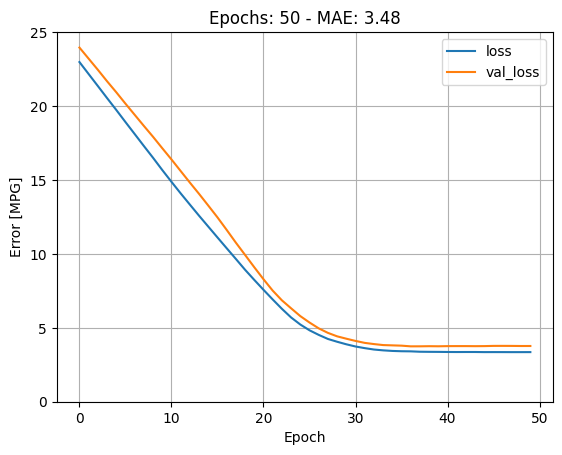

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


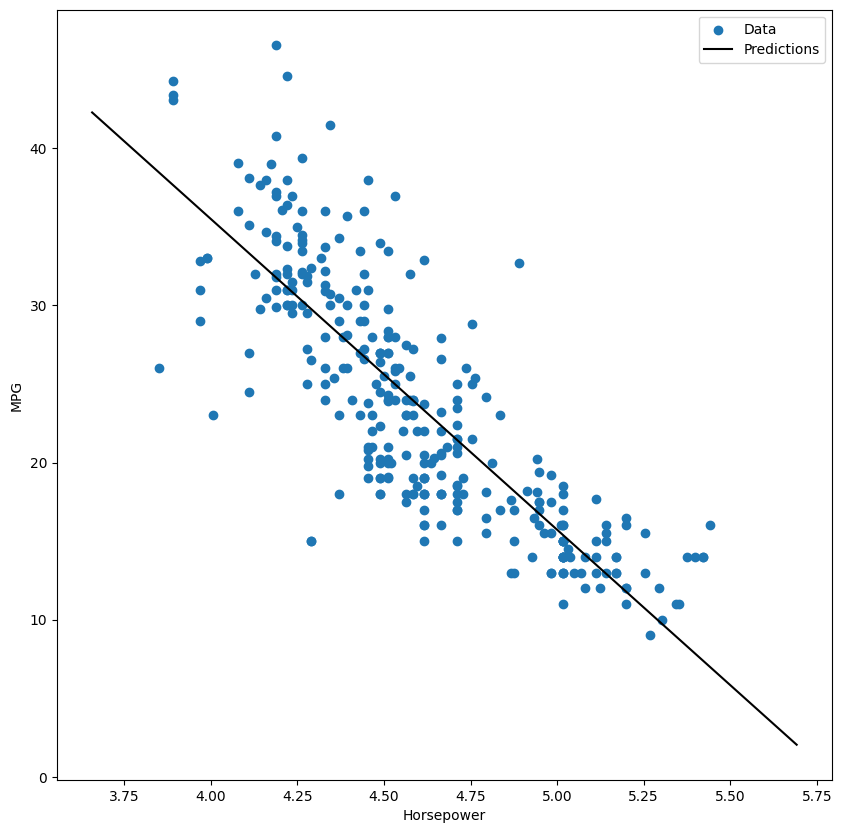

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.9148 - val_loss: 24.2136
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.0975 - val_loss: 23.4574
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21.2838 - val_loss: 22.6974
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.4747 - val_loss: 21.9506
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19.6724 - val_loss: 21.2209
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.8508 - val_loss: 20.4677
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.0357 - val_loss: 19.6863
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.2266 - val_loss: 18.9276
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.4381 - val_loss: 18.1726
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15.6616 - val_loss: 17.3987
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.9030 - val_loss: 16.5978
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.1

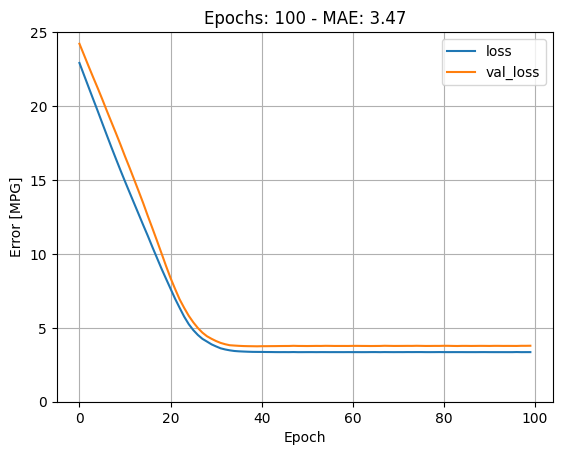

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


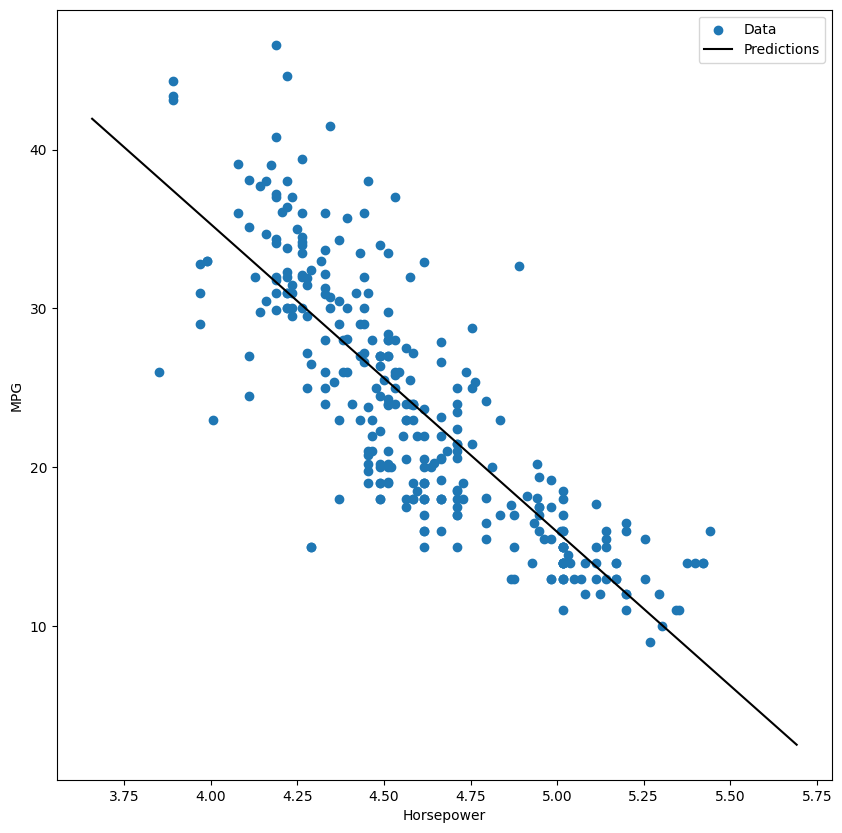

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 22.8859 - val_loss: 24.3222
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.0710 - val_loss: 23.5674
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21.2692 - val_loss: 22.8336
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.4450 - val_loss: 22.0646
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19.6368 - val_loss: 21.2974
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.8269 - val_loss: 20.5383
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.0156 - val_loss: 19.7774
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.2143 - val_loss: 18.9967
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.4426 - val_loss: 18.2424
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.6761 - val_loss: 17.4567
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14.9276 - val_loss: 16.6508
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1

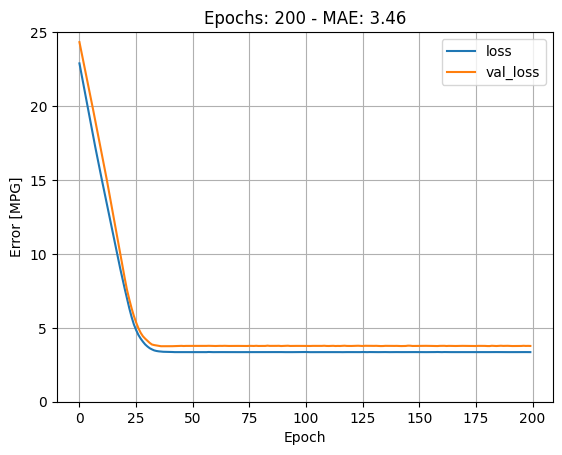

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


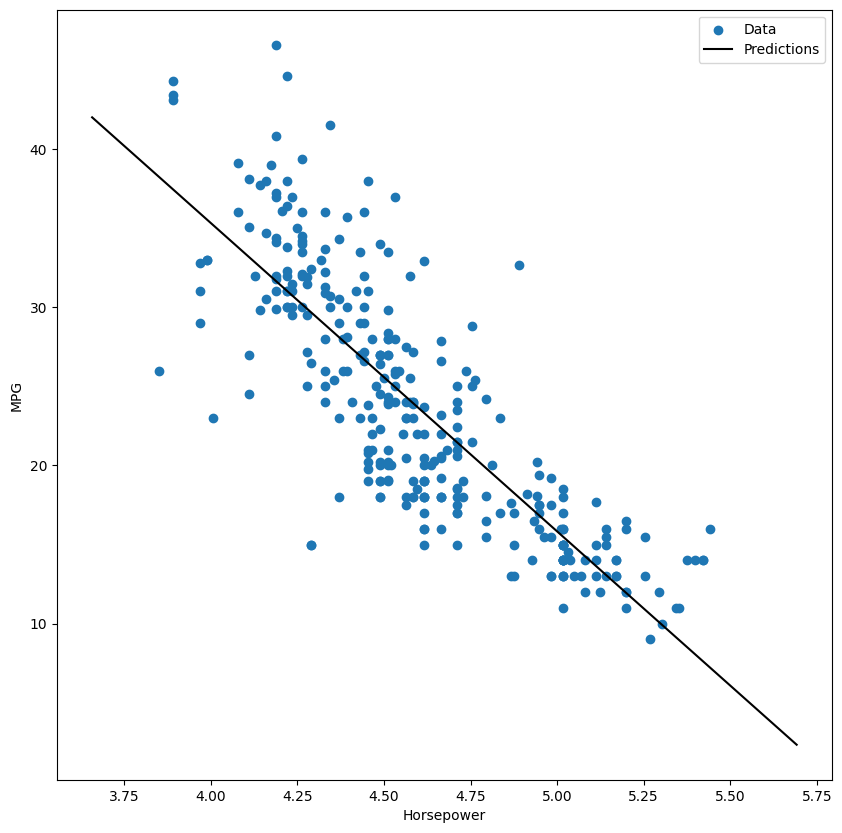

{50: 3.481086492538452, 100: 3.4704902172088623, 200: 3.4645254611968994}


In [29]:
results = {}

for epochs in [50, 100, 200]:
    single_feature_model = build_model(single_feature_normalizer, lr=0.1)
    single_feature_model.summary()
    history = single_feature_model.fit(
        X_train[[feature]], Y_train,
        epochs=epochs,
        verbose=1,
        validation_split=0.2
    )
    mae = single_feature_model.evaluate(X_test[[feature]], Y_test, verbose=1)
    results[epochs] = mae
    plot_loss(history, title=f"Epochs: {epochs} - MAE: {mae:.2f}")
    
    # predict and plot predictions
    range_min = np.min(X_test[feature]) * 0.95
    range_max = np.max(X_test[feature]) * 1.05
    x = tf.linspace(range_min, range_max, 200)
    y = single_feature_model.predict(tf.reshape(x, (-1,1)))

    plot(feature, x, y.flatten())

    all_results.append({
    "Model": "Single-feature linear",
    "Epochs": epochs,
    "Learning rate": 0.1,
    "MAE": mae
    })

print(results)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.1232 - val_loss: 25.2764
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.0423 - val_loss: 25.2007
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.9611 - val_loss: 25.1248
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.8804 - val_loss: 25.0499
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.7987 - val_loss: 24.9721
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.7179 - val_loss: 24.8968
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.6369 - val_loss: 24.8213
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.5557 - val_loss: 24.7454
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.4747 - val_loss: 24.6701
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.3938 - val_loss: 24.5952
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.3125 - val_loss: 24.5195
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.2

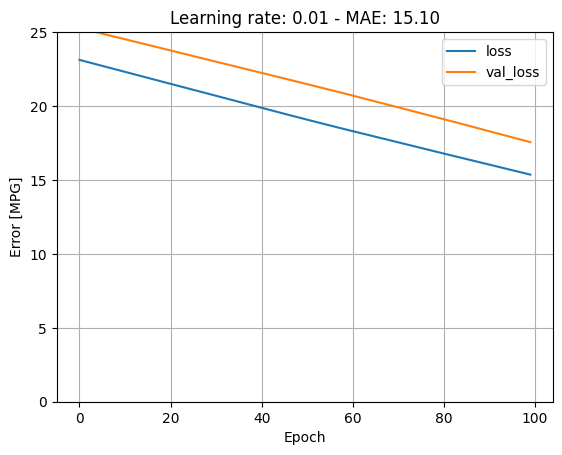

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


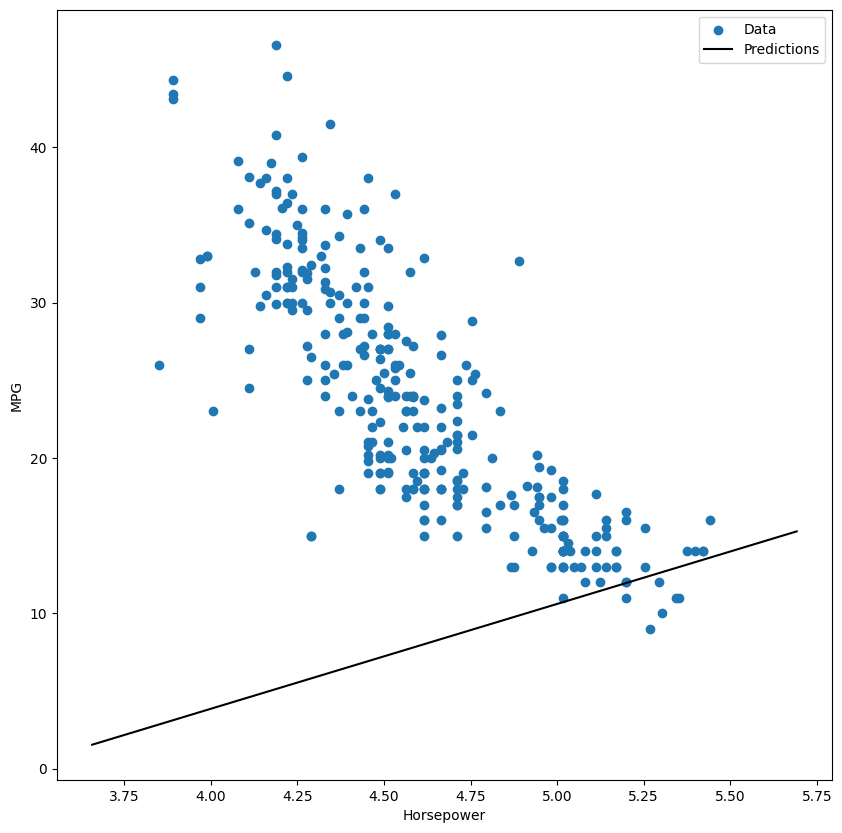

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 22.9197 - val_loss: 24.2263
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.0935 - val_loss: 23.4658
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21.2781 - val_loss: 22.7193
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20.4701 - val_loss: 21.9871
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.6501 - val_loss: 21.2366
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.8440 - val_loss: 20.5026
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.0251 - val_loss: 19.7472
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.2193 - val_loss: 18.9936
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16.4290 - val_loss: 18.2165
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.6661 - val_loss: 17.4257
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.9166 - val_loss: 16.6221
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.1

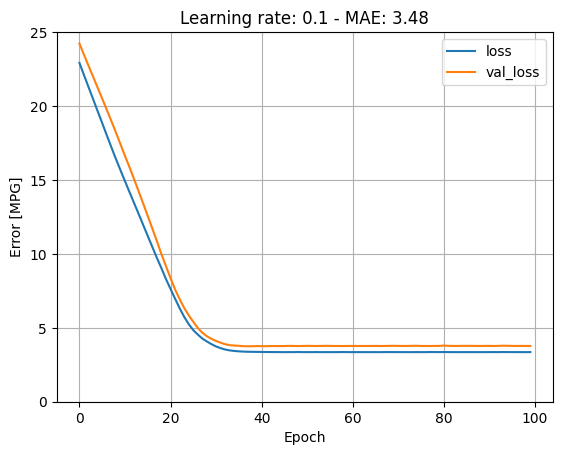

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


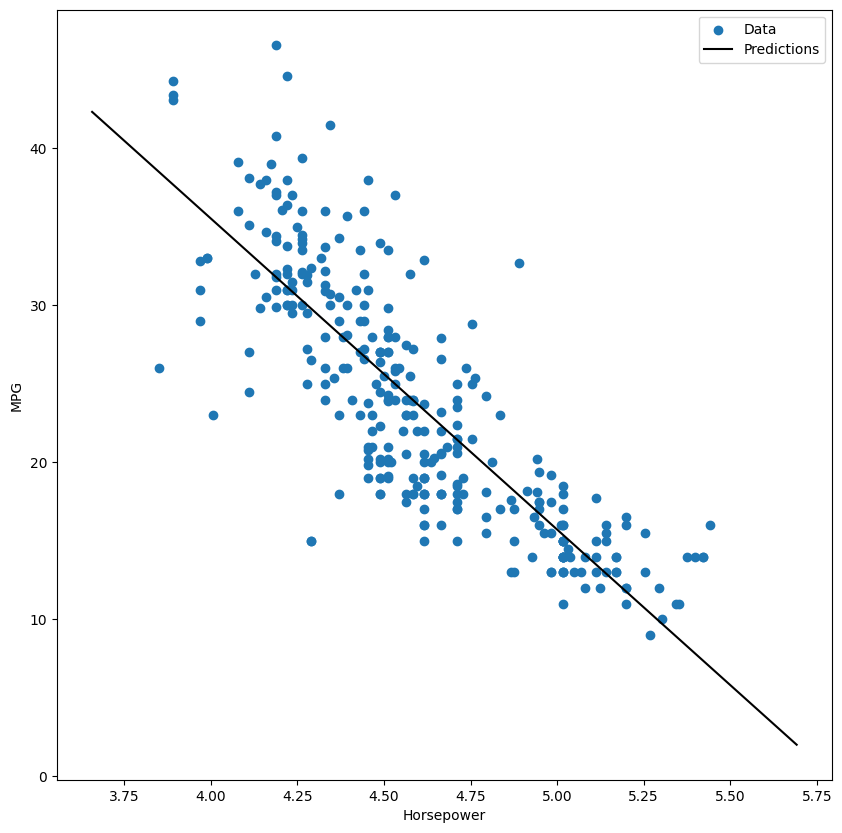

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20.0113 - val_loss: 16.7243
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.0245 - val_loss: 9.8557
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.9190 - val_loss: 4.1073
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8097 - val_loss: 4.4402
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0488 - val_loss: 4.1008
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5017 - val_loss: 3.8237
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5091 - val_loss: 3.7831
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4411 - val_loss: 3.8231
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4168 - val_loss: 3.7971
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3849 - val_loss: 3.8325
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3747 - val_loss: 3.7413
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4024 - val_loss: 3.78

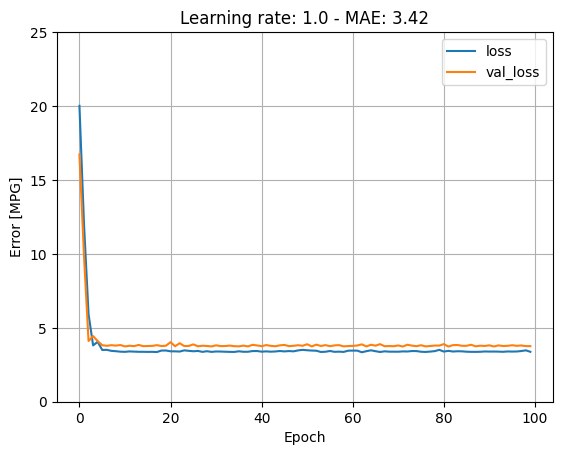

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


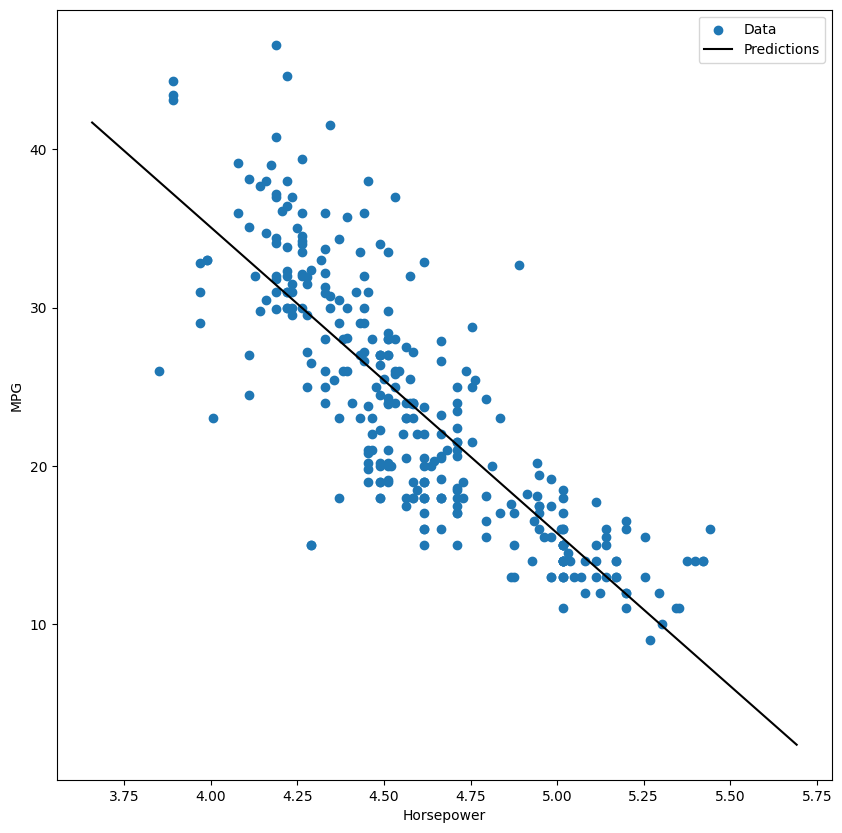

{0.01: 15.102090835571289, 0.1: 3.4838194847106934, 1.0: 3.424091100692749}


In [30]:
results = {}

for learning_rate in [0.01, 0.1, 1.0]:
    single_feature_model = build_model(single_feature_normalizer, lr=learning_rate)
    single_feature_model.summary()
    history = single_feature_model.fit(
        X_train[[feature]], Y_train,
        epochs=100,
        verbose=1,
        validation_split=0.2
    )
    mae = single_feature_model.evaluate(X_test[[feature]], Y_test, verbose=1)
    results[learning_rate] = mae
    plot_loss(history, title=f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    
    # plot predictions
    range_min = np.min(X_test[feature]) * 0.95
    range_max = np.max(X_test[feature]) * 1.05
    x = tf.linspace(range_min, range_max, 200)
    y = single_feature_model.predict(tf.reshape(x, (-1, 1)))

    plot(feature, x, y.flatten())

    all_results.append({
    "Model": "Single-feature linear",
    "Epochs": 100,
    "Learning rate": learning_rate,
    "MAE": mae
    })

print(results)

### Multi feature linear model

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (313, 9)               │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 22.9582 - val_loss: 24.2881
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.0934 - val_loss: 23.6282
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.2331 - val_loss: 23.0595
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.3711 - val_loss: 22.4440
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.5428 - val_loss: 21.8911
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.6736 - val_loss: 21.2611
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.8878 - val_loss: 20.5978
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.1271 - val_loss: 19.7612
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16.3232 - val_loss: 18.9949
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.5527 - val_loss: 18.3252
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.7529 - val_loss: 17.4253
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.9996 - val_lo

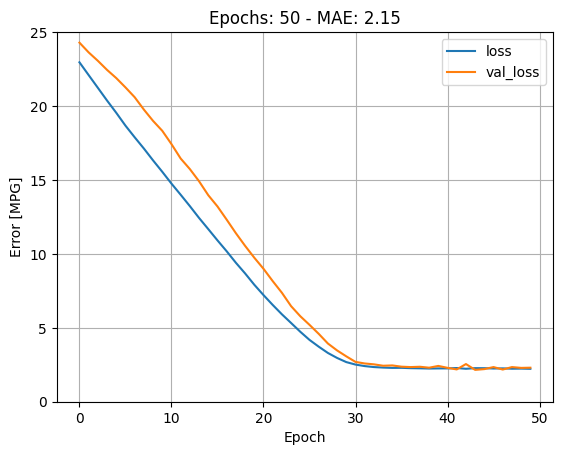

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


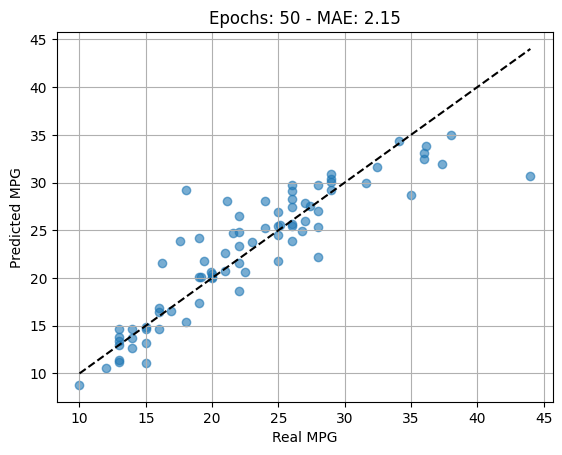

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 22.9039 - val_loss: 24.5785
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.0181 - val_loss: 23.9402
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.1729 - val_loss: 23.3025
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.3441 - val_loss: 22.7274
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.4804 - val_loss: 22.0827
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.7395 - val_loss: 21.3856
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.9042 - val_loss: 20.4529
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.1500 - val_loss: 19.5709
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16.3444 - val_loss: 18.8518
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.5581 - val_loss: 18.0641
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.7886 - val_loss: 17.2547
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.9

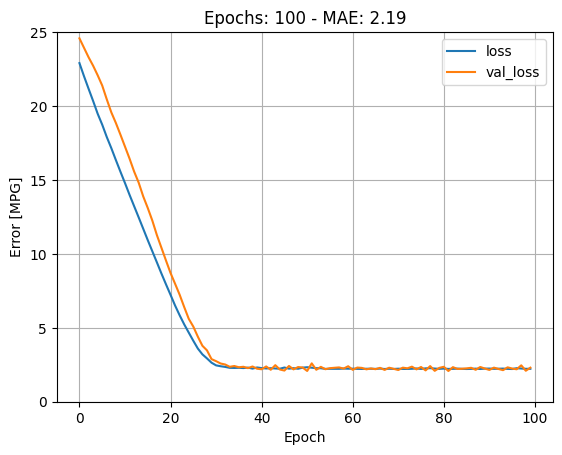

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


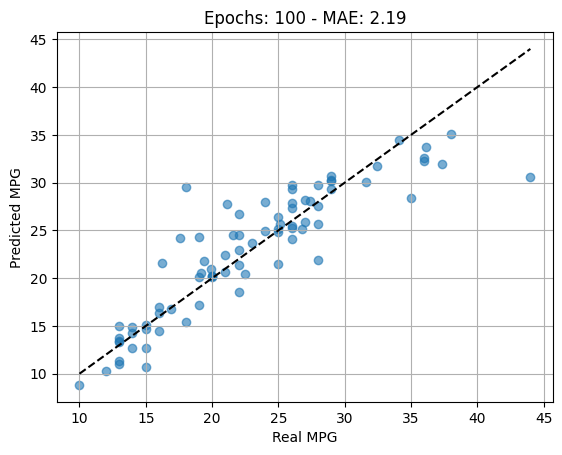

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.9145 - val_loss: 24.4483
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.0161 - val_loss: 23.8714
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.1685 - val_loss: 23.2583
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.3452 - val_loss: 22.7347
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.4520 - val_loss: 22.0830
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.6511 - val_loss: 21.5182
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.8961 - val_loss: 20.8203
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.0921 - val_loss: 19.9424
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16.3438 - val_loss: 19.0338
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.5289 - val_loss: 18.2550
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.7516 - val_loss: 17.4494
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.9

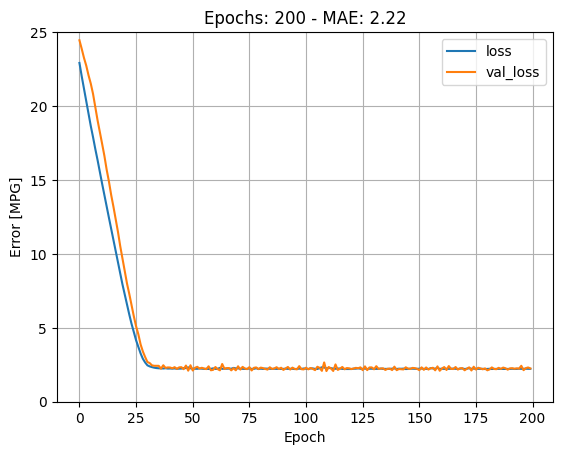

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


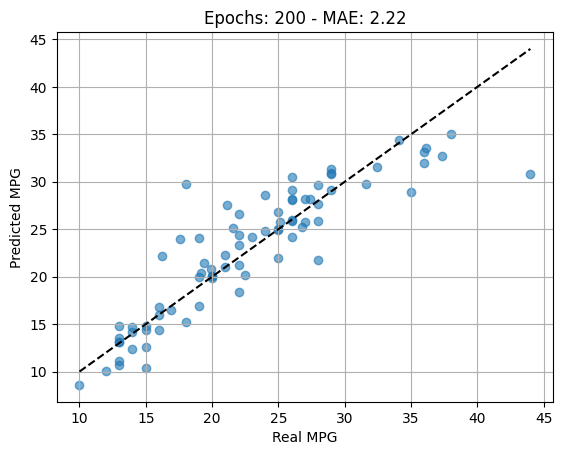

{50: 2.1484575271606445, 100: 2.189178466796875, 200: 2.2209255695343018}


In [31]:
results = {}

for epochs in [50, 100, 200]:
    linear_model = build_model(normalizer, lr=0.1)
    linear_model.summary()
    history = linear_model.fit(
        X_train, Y_train,
        epochs=epochs,
        verbose=1,
        validation_split=0.2
    )
    mae = linear_model.evaluate(X_test, Y_test, verbose=1)
    results[epochs] = mae
    plot_loss(history, title=f"Epochs: {epochs} - MAE: {mae:.2f}")
    
    y_pred = linear_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Epochs: {epochs} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

    all_results.append({
    "Model": "Multi-feature linear",
    "Epochs": epochs,
    "Learning rate": 0.1,
    "MAE": mae
    })

print(results)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 23.2075 - val_loss: 24.9744
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.1223 - val_loss: 24.8992
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.0341 - val_loss: 24.8440
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.9491 - val_loss: 24.7885
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.8660 - val_loss: 24.7351
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.7778 - val_loss: 24.6749
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.6931 - val_loss: 24.6161
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.6064 - val_loss: 24.5457
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.5251 - val_loss: 24.4916
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.4372 - val_loss: 24.4322
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.3520 - val_loss: 24.3685
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.2

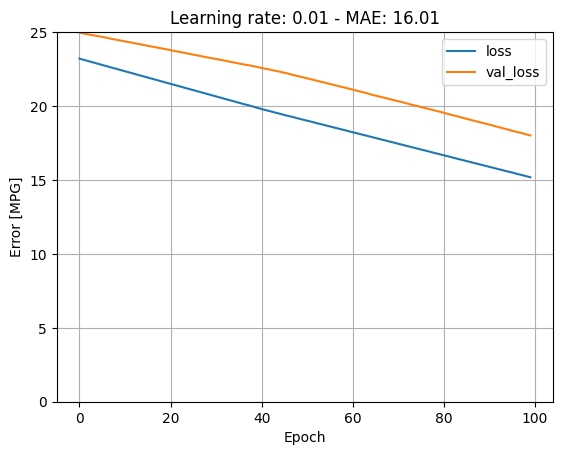

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


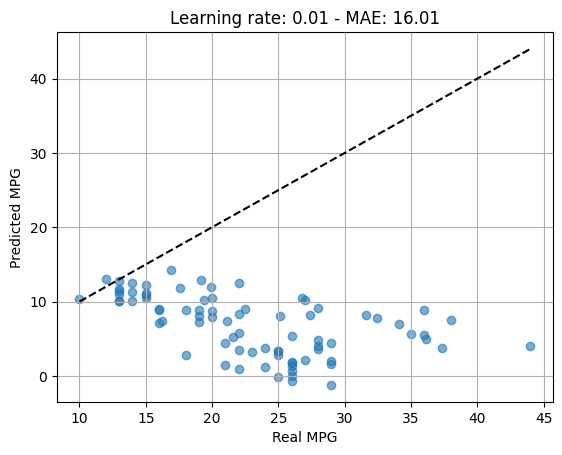

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 22.8938 - val_loss: 24.4911
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.0512 - val_loss: 23.9480
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.1588 - val_loss: 23.3022
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.3821 - val_loss: 22.7560
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.4852 - val_loss: 22.0965
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.6547 - val_loss: 21.4400
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.8855 - val_loss: 20.5976
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.0950 - val_loss: 19.8037
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.3310 - val_loss: 18.9566
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.5763 - val_loss: 18.3257
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.7631 - val_loss: 17.2936
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.0

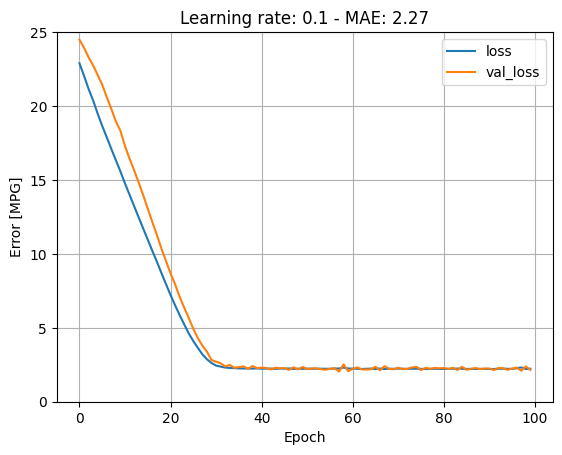

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


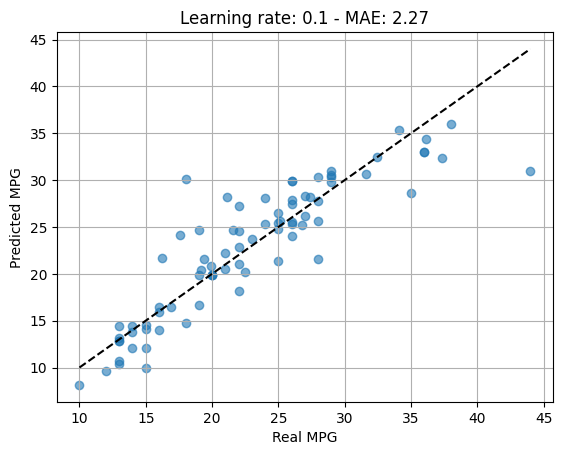

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 20.0539 - val_loss: 17.8803
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.1748 - val_loss: 9.7428
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.2769 - val_loss: 2.9395
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9878 - val_loss: 3.4583
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3629 - val_loss: 2.7372
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6689 - val_loss: 2.8135
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8615 - val_loss: 2.4124
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6779 - val_loss: 2.6591
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7537 - val_loss: 2.0581
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5329 - val_loss: 2.2251
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4129 - val_loss: 2.6073
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3599 - val_loss: 3.24

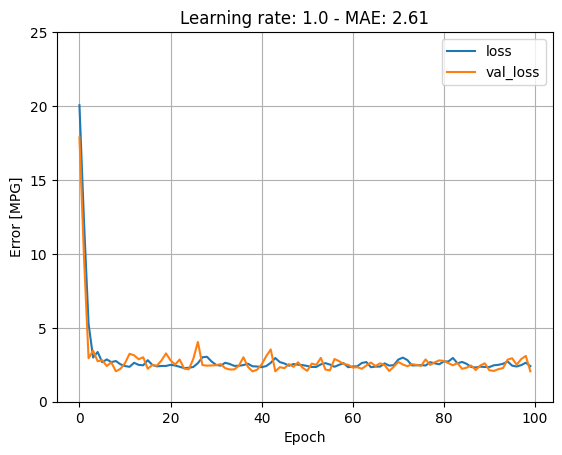

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


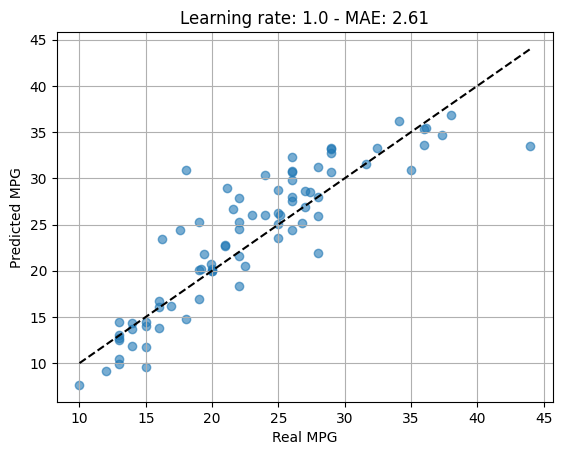

{0.01: 16.006595611572266, 0.1: 2.268076181411743, 1.0: 2.612276315689087}


In [32]:
results = {}

for learning_rate in [0.01, 0.1, 1.0]: 
    linear_model = build_model(normalizer, lr=learning_rate)
    linear_model.summary()
    history = linear_model.fit(
        X_train, Y_train,
        epochs=100,
        verbose=1,
        validation_split=0.2
    )
    mae = linear_model.evaluate(X_test, Y_test, verbose=1)
    results[learning_rate] = mae
    plot_loss(history, title=f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    
    y_pred = linear_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

    all_results.append({
        "Model": "Multi-feature linear",
        "Epochs": 100,
        "Learning rate": learning_rate,
        "MAE": mae
    })

print(results)

## Eksperyment z siecią nieliniową

W ramach posiadania jakiegoś punktu odniesiena względem prostych sieci liniowych w tej części zostaną przeprowadzone dokładnie takie same eksperymenty, ale z użyciem modelu sieci nieliniowej (głebokiej).

In [33]:
def build_deep_model(normalizer, lr):
    model = keras.models.Sequential([
        normalizer,
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.MeanAbsoluteError()
    )
    return model

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 16.1636 - val_loss: 7.6910
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.9589 - val_loss: 4.4462
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0686 - val_loss: 3.9102
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2226 - val_loss: 2.8640
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5400 - val_loss: 3.4477
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7370 - val_loss: 4.7054
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6698 - val_loss: 2.5002
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2825 - val_loss: 2.4118
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3244 - val_loss: 2.7339
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6580 - val_loss: 2.2237
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5681 - val_loss: 2.4956
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4687 - val_loss: 2.0664
Epoch 13/50

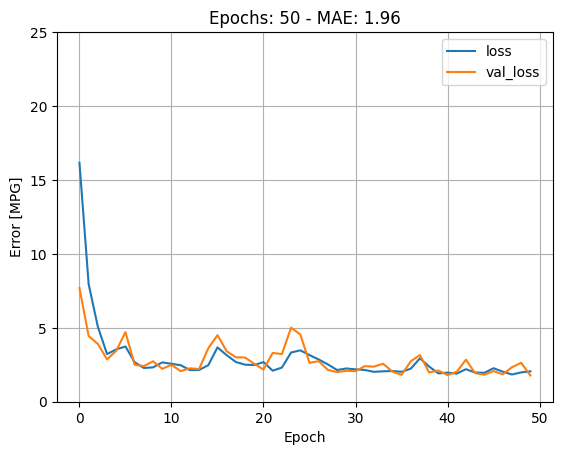

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


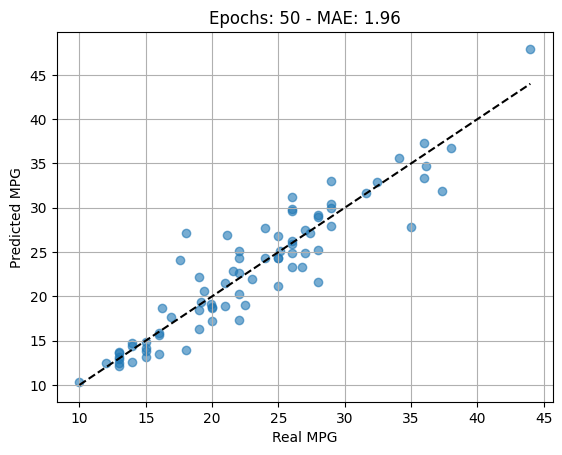

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 12.7740 - val_loss: 18.7540
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.2462 - val_loss: 7.8971
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.0067 - val_loss: 4.5195
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.0356 - val_loss: 3.1691
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.0067 - val_loss: 3.4957
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9593 - val_loss: 4.0388
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2952 - val_loss: 3.3793
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4861 - val_loss: 2.4757
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5484 - val_loss: 2.1982
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4567 - val_loss: 2.1923
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4043 - val_loss: 2.3910
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1387 - val_loss: 1.988

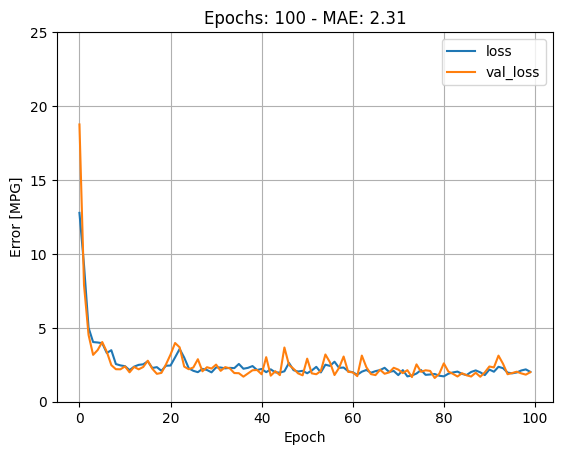

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


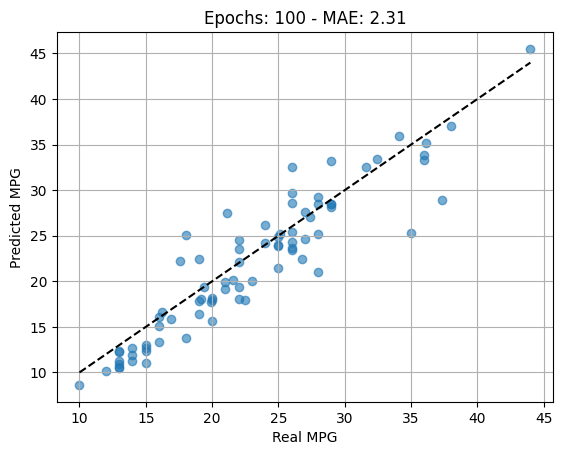

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 14.7951 - val_loss: 10.1473
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4608 - val_loss: 4.5424
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.7090 - val_loss: 5.1635
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2829 - val_loss: 5.8119
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2955 - val_loss: 4.0560
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3490 - val_loss: 2.9582
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0724 - val_loss: 2.8838
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6265 - val_loss: 2.2772
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5499 - val_loss: 2.0175
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3246 - val_loss: 2.2872
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3870 - val_loss: 2.1850
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3378 - val_loss: 2.537

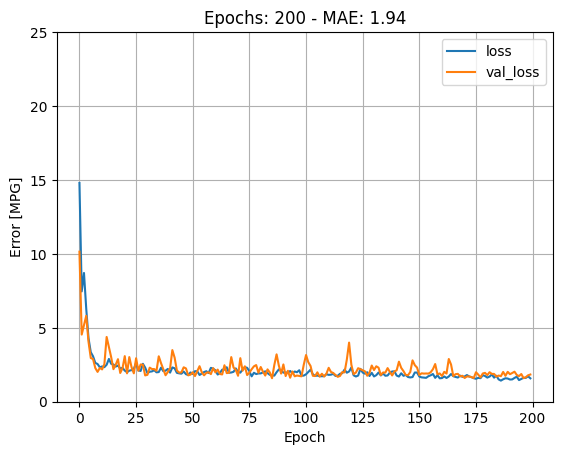

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


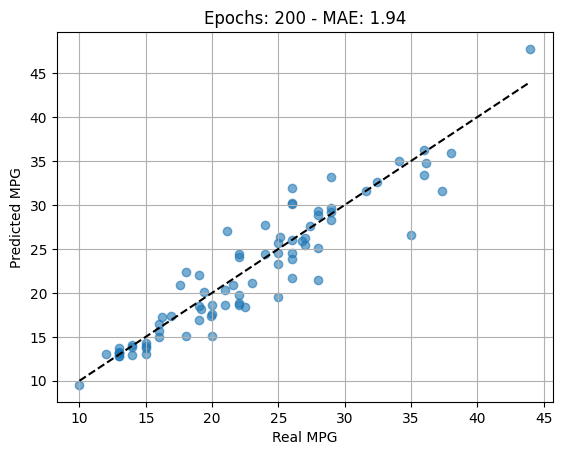

{50: 1.963319182395935, 100: 2.3137106895446777, 200: 1.9364932775497437}


In [34]:
results = {}

for epochs in [50, 100, 200]:
    dnn_model = build_deep_model(normalizer, lr=0.1)
    dnn_model.summary()
    history = dnn_model.fit(
        X_train, Y_train,
        epochs=epochs,
        verbose=1,
        validation_split=0.2
    )
    mae = dnn_model.evaluate(X_test, Y_test, verbose=1)
    results[epochs] = mae
    plot_loss(history, title=f"Epochs: {epochs} - MAE: {mae:.2f}")
    
    y_pred = dnn_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Epochs: {epochs} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

    all_results.append({
        "Model": "DNN",
        "Epochs": epochs,
        "Learning rate": 0.1,
        "MAE": mae
    })

print(results)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 19.3229 - val_loss: 14.2689
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7500 - val_loss: 7.4399
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7445 - val_loss: 5.1106
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0646 - val_loss: 2.7796
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9315 - val_loss: 2.4987
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5362 - val_loss: 2.0773
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2834 - val_loss: 2.9719
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4217 - val_loss: 2.2703
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2472 - val_loss: 1.8233
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0225 - val_loss: 1.8723
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1828 - val_loss: 2.0805
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1364 - val_loss: 2.161

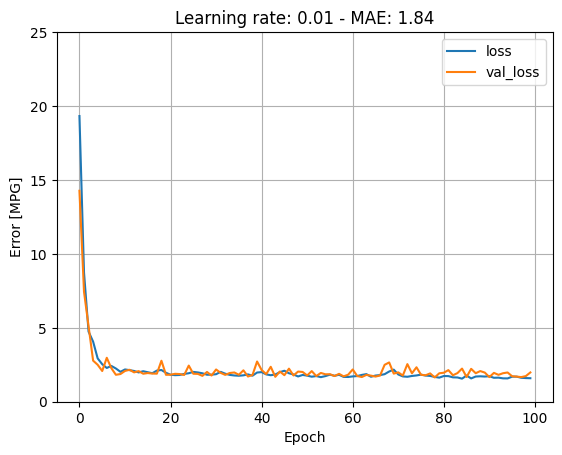

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


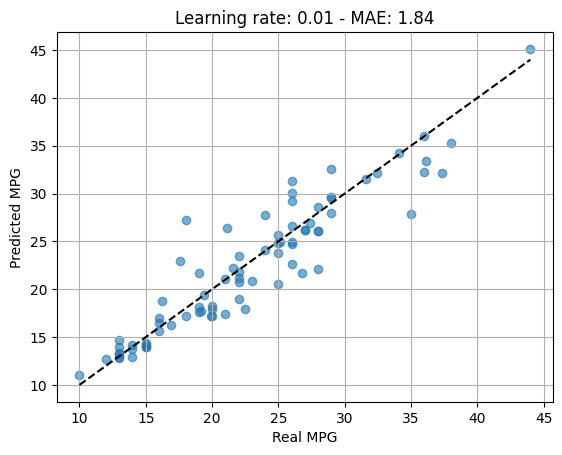

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 11.9551 - val_loss: 4.1075
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1424 - val_loss: 5.3308
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8755 - val_loss: 4.1582
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9533 - val_loss: 4.8766
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5440 - val_loss: 2.6486
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9054 - val_loss: 2.6086
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1287 - val_loss: 4.1652
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0692 - val_loss: 3.9197
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8640 - val_loss: 4.4134
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9963 - val_loss: 2.2472
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3975 - val_loss: 3.8044
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9855 - val_loss: 3.8006

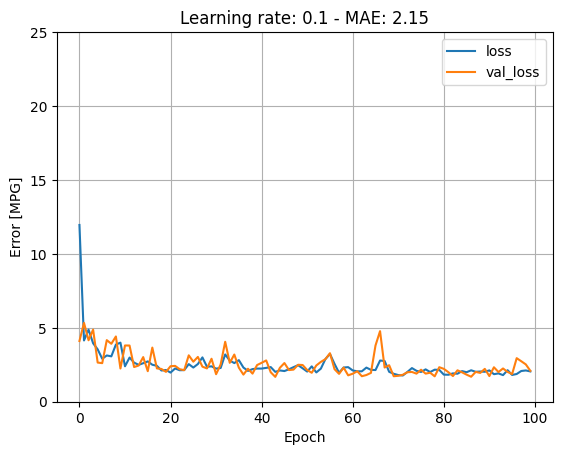

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


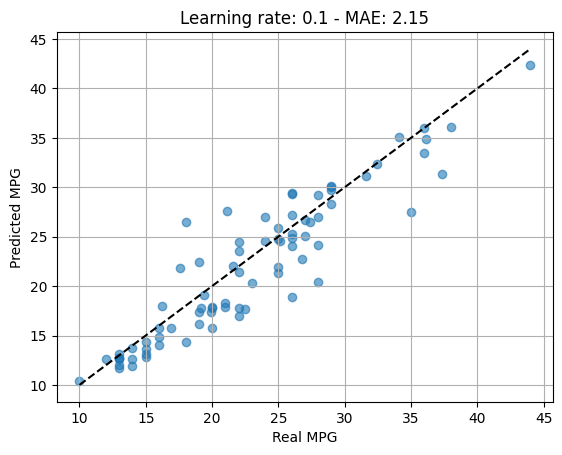

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 771.9550 - val_loss: 22.6831
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 18.3456 - val_loss: 16.3214
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.5699 - val_loss: 9.7148
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.1786 - val_loss: 7.1399
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.7685 - val_loss: 6.7626
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.9165 - val_loss: 6.7718
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.8319 - val_loss: 6.7648
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.7041 - val_loss: 7.0494
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.6385 - val_loss: 7.2567
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.6411 - val_loss: 7.1968
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.6311 - val_loss: 7.2811
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.6328 - val

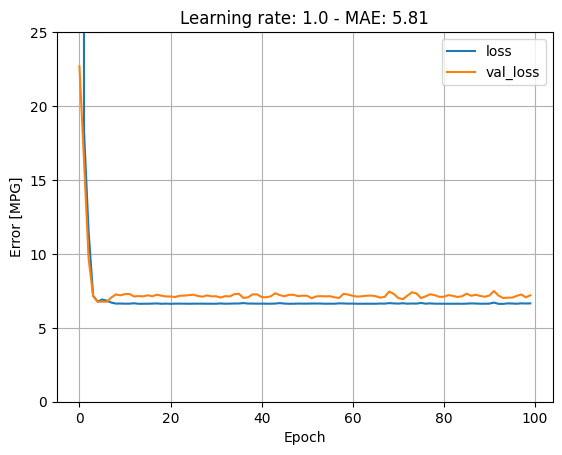

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


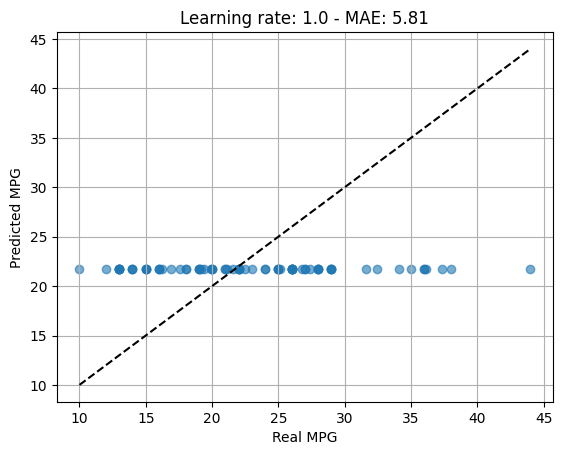

{0.01: 1.83724045753479, 0.1: 2.145763874053955, 1.0: 5.805045127868652}


In [35]:
results = {}

for learning_rate in [0.01, 0.1, 1.0]: 
    dnn_model = build_deep_model(normalizer, lr=learning_rate)
    dnn_model.summary()
    history = dnn_model.fit(
        X_train, Y_train,
        epochs=100,
        verbose=1,
        validation_split=0.2
    )
    mae = dnn_model.evaluate(X_test, Y_test, verbose=1)
    results[learning_rate] = mae
    plot_loss(history, title=f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    
    y_pred = dnn_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

    all_results.append({
        "Model": "DNN",
        "Epochs": 100,
        "Learning rate": learning_rate,
        "MAE": mae
    })

print(results)

## Analiza Wyników

Po przeprowadzeniu eksperymentów dla trzech architektur sieci neuronowej - modelu liniowego jednocechowego (single-feature), modelu liniowego wielocechowego (multi-feature) oraz głębokiej sieci neuronowej (DNN) - zebrane wyniki pozwalają na ich wzajemne porównanie oraz ocenę wpływu poszczególnych parametrów treningu na jakość predykcji.

Najlepszy wynik osiągnął model `DNN` z MAE równym [1.783056] `MPG` przy [100] epokach i learning rate równym [0.10].

Zgodnie z oczekiwaniami model liniowy oparty na pojedynczej cesze (Horsepower) osiągnął najsłabsze wyniki - MAE na poziomie [3.466164] `MPG` w najlepszej próbie - co potwierdza, że sama moc silnika nie jest wystarczającym predyktorem spalania. Dodanie wszystkich cech w modelu multi-feature poprawiło MAE do [2.169660] `MPG`, co pokazuje że cechy takie jak masa pojazdu czy pojemność skokowa wnoszą istotną informację predykcyjną.

Model DNN osiągnął MAE równe [1.783056] `MPG`, co stanowi poprawę względem modelu liniowego multi-feature. Wynik ten sugeruje, że zależność między cechami a spalaniem ma charakter częściowo nieliniowy, który model liniowy nie jest w stanie w pełni uchwycić.

Analiza residuałów wykazała że błędy predykcji są w przybliżeniu symetrycznie rozłożone wokół zera, co potwierdza że model nie ma systematycznego błędu (biasu) w predykcji.

In [36]:
summary = pd.DataFrame(all_results)
summary = summary.sort_values("MAE").reset_index(drop=True)
summary

,Model,Epochs,Learning rate,MAE
0,DNN,100,0.01,1.837240
1,DNN,200,0.10,1.936493
2,DNN,50,0.10,1.963319
3,DNN,100,0.10,2.145764
4,Multi-feature linear,50,0.10,2.148458
5,Multi-feature linear,100,0.10,2.189178
6,Multi-feature linear,200,0.10,2.220926
7,Multi-feature linear,100,0.10,2.268076
8,DNN,100,0.10,2.313711
9,Multi-feature linear,100,1.00,2.612276


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


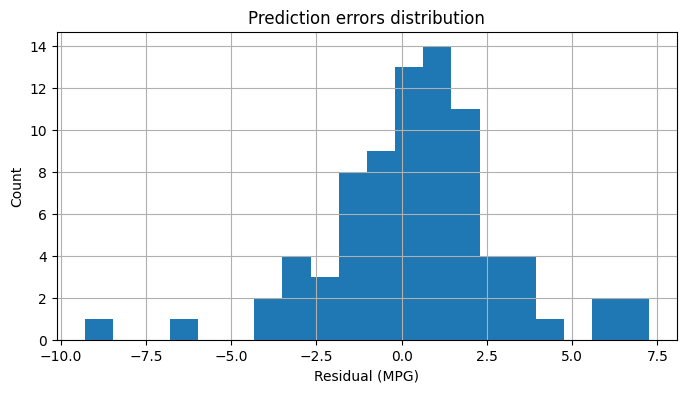

,Real MPG,Predicted MPG,Abs Error
73,18.0,27.286011,9.286011
19,35.0,27.755667,7.244333
52,28.0,21.042305,6.957695
64,21.1,27.755632,6.655632
58,25.0,18.750957,6.249043


In [37]:
# Use the best model and once again perform a training and test session
best_model = build_deep_model(normalizer, lr=0.1)
best_model.fit(X_train, Y_train, epochs=100, verbose=0, validation_split=0.2)

y_pred = best_model.predict(X_test).flatten()
residuals = Y_test.values - y_pred

# Plot the prediction errors distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=20)
plt.xlabel("Residual (MPG)")
plt.ylabel("Count")
plt.title("Prediction errors distribution")
plt.grid(True)
plt.show()

# Biggest errors
errors = pd.DataFrame({
    "Real MPG": Y_test.values,
    "Predicted MPG": y_pred,
    "Abs Error": np.abs(residuals)
})
errors.nlargest(5, "Abs Error")

## Podsumowanie oraz wnioski

Projekt zrealizował pełny pipeline uczenia maszynowego dla problemu regresji: od eksploracji i preprocessingu danych, przez trening i ewaluację modeli, po analizę wyników. Poniżej zebrano kluczowe wnioski.

**Preprocessing ma kluczowe znaczenie** - zastosowanie transformacji `log1p` dla cech o rozkładzie prawostronnie skośnym (Horsepower, Displacement, Weight) oraz normalizacja cech do zakresu o średniej 0 i odchyleniu standardowym 1 istotnie poprawiają stabilność i szybkość treningu sieci neuronowej.

**Liczba cech ma większy wpływ niż liczba epok** - model single-feature osiągnął MAE ~3.47 MPG, podczas gdy model multi-feature przy tych samych parametrach uzyskał MAE ~2.17 MPG. Zwiększanie liczby epok powyżej 100 nie przyniosło istotnej poprawy dla modeli liniowych, co sugeruje że model osiąga granicę swojej pojemności.

**Regresja liniowa ma ograniczenia dla tego datasetu** - DNN z warstwami ReLU osiągnął MAE ~1.78 MPG, co potwierdza że zależność między cechami technicznymi samochodu a spalaniem nie jest w pełni liniowa. Model liniowy nie jest w stanie uchwycić interakcji między cechami.

**Learning rate 0.1 okazał się optymalny** - zarówno dla modeli liniowych jak i DNN. Zbyt mała wartość (0.01) spowalniała zbieżność, zbyt duża (1.0)
powodowała niestabilność treningu.

**Ograniczenia projektu** - dataset zawiera jedynie 392 próbki z lat 1970-1982, co ogranicza generalizację modelu na współczesne pojazdy. Większy i bardziej zróżnicowany zbiór danych prawdopodobnie pozwoliłby na uzyskanie lepszych wyników, szczególnie dla modelu DNN.